<a href="https://colab.research.google.com/github/AnshuSai26/AgenticAI/blob/main/PlantSpecies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Setup and Drive Mounting

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
import os

# Mount Google Drive (will prompt for authorization)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")
except ImportError:
    print("Not running in Colab. Ensure local path configuration is correct.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


In [6]:
# Cell 2: Configuration and Data Preparation

import pandas as pd
import os
from sklearn.model_selection import train_test_split
import tensorflow as tf

# --- USER CONFIGURATION (YOU MUST CHANGE THESE) ---
# ⚠️ 1. Base path to your 'leaf' folder in Google Drive.
# Example: '/content/gdrive/MyDrive/Flavia_Project/leaf/'
DRIVE_PATH = '/content/drive/MyDrive/leaf/'

# ⚠️ 2. Full path to the 'Leaves' folder containing all your images.
IMAGE_DIR = DRIVE_PATH + 'Leaves/'

# Path to the CSV file (assumes all.csv is directly in the 'leaf' folder)
CSV_PATH = DRIVE_PATH + 'all.csv'
# --------------------------

# Global Parameters
IMG_WIDTH = 128
IMG_HEIGHT = 128
CHANNELS = 3
BATCH_SIZE = 32
EPOCHS = 30
RANDOM_SEED = 42

# 1. Load the labels file (all.csv) using the full Drive path
try:
    df = pd.read_csv(CSV_PATH)

    # Rename columns based on the file's structure: index, image_filename, label
    df.columns = ['_drop', 'filename', 'label']
    df = df.drop(columns=['_drop'])
    print(f"CSV loaded successfully from: {CSV_PATH}")

except FileNotFoundError:
    print(f"\nFATAL ERROR: 'all.csv' not found at the path: {CSV_PATH}")
    print("Please correct the 'DRIVE_PATH' variable in the code above and re-run.")
    raise

# Determine number of classes
NUM_CLASSES = df['label'].nunique()
print(f"\nDetected {NUM_CLASSES} unique leaf species.")

# 2. Create full image file paths
df['filepath'] = IMAGE_DIR + df['filename']

# Verify the image directory exists
if not os.path.isdir(IMAGE_DIR):
    print(f"\nFATAL ERROR: Image directory '{IMAGE_DIR}' not found. Check your 'IMAGE_DIR' path!")
    raise FileNotFoundError("Image directory not found.")

# 3. Split data into training and validation sets
train_df, val_df = train_test_split(
    df,
    test_size=0.2, # 80% Train, 20% Validation
    stratify=df['label'],
    random_state=RANDOM_SEED
)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

# --- tf.data Pipeline Functions ---

# Function to load and preprocess a single image
def load_and_preprocess_image(filepath, label):
    """Loads, resizes, normalizes, and one-hot encodes labels."""
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=CHANNELS)
    img = tf.image.resize(img, [IMG_WIDTH, IMG_HEIGHT])
    img = img / 255.0  # Normalize pixel values
    label = tf.one_hot(label, depth=NUM_CLASSES)
    return img, label

# Function to create tf.data.Dataset from a DataFrame
def create_tf_dataset(dataframe, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (dataframe['filepath'].values, dataframe['label'].values)
    )

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe), seed=RANDOM_SEED)

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset

# 4. Create the final datasets
train_ds = create_tf_dataset(train_df, shuffle=True)
val_ds = create_tf_dataset(val_df)

print("tf.data datasets created and ready for model consumption.")

CSV loaded successfully from: /content/drive/MyDrive/leaf/all.csv

Detected 32 unique leaf species.
Training samples: 1525
Validation samples: 382
tf.data datasets created and ready for model consumption.


In [9]:
# Cell 3: CNN Model Training, Evaluation, and Saving

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# 1. Define the CNN Model Architecture
def build_cnn_model():
    model = Sequential([
        # Feature Extraction Blocks
        Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_WIDTH, IMG_HEIGHT, CHANNELS)),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        # Classification Head
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),

        # Output layer (number of classes)
        Dense(NUM_CLASSES, activation='softmax')
    ])

    # Compile the model
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create and summarize the model
model = build_cnn_model()
model.summary()


# 2. Train the model
print("\n--- Starting Model Training ---")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# 3. Evaluate and Save
print("\n--- Final Evaluation ---")
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy*100:.2f}%")

# Save the trained model to Google Drive
model_save_path = DRIVE_PATH + 'plant_leaf_cnn_model.h5'
model.save(model_save_path)
print(f"\nModel saved successfully to: {model_save_path}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │        16,416 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,955,232 (49.42 MB)

 Trainable params: 12,955,232 (49.42 MB)

 Non-trainable params: 0 (0.00 B)


--- Starting Model Training ---
Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 41s 735ms/step - accuracy: 0.1513 - loss: 3.2141 - val_accuracy: 0.6440 - val_loss: 1.2052
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 28s 585ms/step - accuracy: 0.6496 - loss: 1.1910 - val_accuracy: 0.7801 - val_loss: 0.7829
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 27s 569ms/step - accuracy: 0.7729 - loss: 0.7421 - val_accuracy: 0.8220 - val_loss: 0.5793
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 41s 572ms/step - accuracy: 0.8409 - loss: 0.5240 - val_accuracy: 0.8298 - val_loss: 0.5238
Epoch 5/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 28s 591ms/step - accuracy: 0.8651 - loss: 0.4593 - val_accuracy: 0.8743 - val_loss: 0.4068
Epoch 6/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 28s 579ms/step - accuracy: 0.9153 - loss: 0.2726 - val_accuracy: 0.9005 - val_loss: 0.4162
Epoch 7/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 41s 573ms/step - accuracy: 0.9260 - loss: 0.1978 - val_accuracy: 0.8691 - val_loss: 0.4483
Epoch 8/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 42s 588ms/step - accuracy:

Validation Loss: 0.4120
Validation Accuracy: 92.41%

Model saved successfully to: /content/drive/MyDrive/leaf/plant_leaf_cnn_model.h5


In [12]:
# Cell 4: Load Model and Make a Prediction

import tensorflow as tf
import numpy as np
from tensorflow.keras.models import load_model
import os

# --- USER CONFIGURATION (CHANGE THESE) ---
# ⚠️ 1. Base path to your 'leaf' folder (same as DRIVE_PATH in Cell 2)
DRIVE_PATH = '/content/drive/MyDrive/leaf/'
# ⚠️ 2. Full path to the saved model file
MODEL_SAVE_PATH = DRIVE_PATH + 'plant_leaf_cnn_model.h5'
# ⚠️ 3. Full path to a NEW image you want to classify (e.g., from your Leaves folder)
NEW_IMAGE_FILENAME = '1304.jpg' # REPLACE with an actual filename
NEW_IMAGE_PATH = DRIVE_PATH + 'Leaves/' + NEW_IMAGE_FILENAME
# ----------------------------------------

# Re-define parameters used for image preprocessing
IMG_WIDTH = 128
IMG_HEIGHT = 128
CHANNELS = 3

# 1. Load the trained model
try:
    loaded_model = load_model(MODEL_SAVE_PATH)
    print("Model loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")
    exit()

# 2. Define the preprocessing function (must match training preprocessing)
def preprocess_new_image(filepath):
    """Loads, resizes, and normalizes a single image."""
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=CHANNELS)
    img = tf.image.resize(img, [IMG_WIDTH, IMG_HEIGHT])
    img = img / 255.0  # Normalize
    return img

# 3. Load and preprocess the new image
new_img = preprocess_new_image(NEW_IMAGE_PATH)

# Models expect a batch of images, so we add an extra dimension (axis=0)
image_batch = np.expand_dims(new_img, axis=0)

# 4. Make the prediction
print(f"\nMaking prediction for: {NEW_IMAGE_FILENAME}...")
predictions = loaded_model.predict(image_batch)

# 5. Get the predicted class index and confidence
predicted_class_index = np.argmax(predictions[0])
confidence = np.max(predictions[0]) * 100

print("--- Prediction Result ---")
print(f"Predicted Species (Species ID): {predicted_class_index}")
print(f"Confidence: {confidence:.2f}%")
print("-------------------------")

Model loaded successfully.

Making prediction for: 1304.jpg...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 647ms/step
--- Prediction Result ---
Predicted Species (Species ID): 5
Confidence: 100.00%
-------------------------


Model loaded successfully.

Making prediction for: 1567.jpg...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step


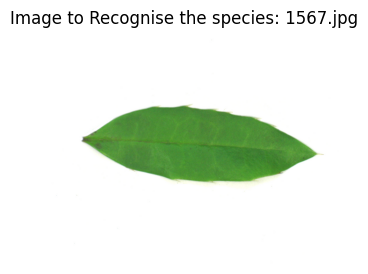


--- Prediction Result ---
Predicted Class Index (Species ID): 2
Confidence: 100.00%
-------------------------


In [15]:
# Cell 4: Load Model and Make a Prediction

import tensorflow as tf
import numpy as np
from tensorflow.keras.models import load_model
import os
# New import for image display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# --- USER CONFIGURATION (CHANGE THESE) ---
# ⚠️ 1. Base path to your 'leaf' folder (same as DRIVE_PATH in Cell 2)
DRIVE_PATH = '/content/drive/MyDrive/leaf/'
# ⚠️ 2. Full path to the saved model file
MODEL_SAVE_PATH = DRIVE_PATH + 'plant_leaf_cnn_model.h5'
# ⚠️ 3. Full path to a NEW image you want to classify (e.g., from your Leaves folder)
NEW_IMAGE_FILENAME = '1567.jpg' # REPLACE with an actual filename
NEW_IMAGE_PATH = DRIVE_PATH + 'Leaves/' + NEW_IMAGE_FILENAME
# ----------------------------------------

# Re-define parameters used for image preprocessing
IMG_WIDTH = 128
IMG_HEIGHT = 128
CHANNELS = 3

# 1. Load the trained model
try:
    loaded_model = load_model(MODEL_SAVE_PATH)
    print("Model loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")
    # exit() # Keep this line if you want the script to stop on error

# 2. Define the preprocessing function (must match training preprocessing)
def preprocess_new_image(filepath):
    """Loads, resizes, and optionally normalizes a single image."""
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=CHANNELS)
    img = tf.image.resize(img, [IMG_WIDTH, IMG_HEIGHT])
    img = img / 255.0 # Normalize for the model
    return img

# 3. Load and preprocess the new image
new_img_for_model = preprocess_new_image(NEW_IMAGE_PATH) # For model input

# 4. Load the image again for display (matplotlib expects a standard image load)
try:
    img_display = mpimg.imread(NEW_IMAGE_PATH)
except FileNotFoundError:
    print(f"\n⚠️ Error: The image file was not found at {NEW_IMAGE_PATH}")
    exit()

# Models expect a batch of images, so we add an extra dimension (axis=0)
image_batch = np.expand_dims(new_img_for_model, axis=0)

# 5. Make the prediction
print(f"\nMaking prediction for: {NEW_IMAGE_FILENAME}...")
predictions = loaded_model.predict(image_batch)

# 6. Get the predicted class index and confidence
predicted_class_index = np.argmax(predictions[0])
confidence = np.max(predictions[0]) * 100

# 7. --- DISPLAY IMAGE AND RESULTS ---

# Display the image
plt.figure(figsize=(4, 4))
plt.imshow(img_display) # Use the image loaded for display
plt.title(f"Image to Recognise the species: {NEW_IMAGE_FILENAME}")
plt.axis('off')
plt.show()

# Print the prediction results
print("\n--- Prediction Result ---")
print(f"Predicted Class Index (Species ID): {predicted_class_index}")
print(f"Confidence: {confidence:.2f}%")
print("-------------------------")